# Train YOLOv8 License Plate Detector (Open Images → YOLO format)

This notebook prepares an Open Images–based dataset (like the referenced guide) and trains a YOLOv8 detector.

**Goal for this ANPR repo:** export the trained weights to `./models/` so you can use it as:
- `./models/license_plate_detector.pt` (used by `main.py` and `live.py`)

## 1) Notebook Parameters & Paths (set `models/` export directory)

Edit variables in the next cell as needed. All paths are relative to the repo root.

In [19]:
from __future__ import annotations

from pathlib import Path


def _has_repo_markers(p: Path) -> bool:
    return (p / "main.py").exists() and (p / "requirements.txt").exists()


def _guess_repo_root(start: Path, search_depth: int = 4) -> Path:
    """Try hard to locate the ANPR repo root so artifacts land in ./models on your machine."""
    start = start.resolve()

    # 1) Walk up parents first
    for p in [start, *start.parents]:
        if _has_repo_markers(p):
            return p

    # 2) Depth-limited search downward (helps when cwd is not the repo root, e.g., /content)
    candidates: list[Path] = []
    for path in start.rglob("main.py"):
        try:
            rel = path.relative_to(start)
        except Exception:
            continue
        if len(rel.parts) > search_depth:
            continue
        repo = path.parent
        if _has_repo_markers(repo):
            candidates.append(repo)

    # Prefer the shallowest match
    if candidates:
        candidates.sort(key=lambda p: len(p.relative_to(start).parts))
        return candidates[0]

    # Fallback: leave as-is, but warn
    return start


# If you know the repo path, you can hardcode it here, e.g.:
# ROOT = Path(r"C:\\path\\to\\automatic-number-plate-recognition-python-yolov8")
ROOT = _guess_repo_root(Path.cwd())

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"  # working directory for this notebook
PREPARE_DATA_DIR = DATA_DIR / "prepare_data"
RAW_DIR = DATA_DIR / "raw"
RAW_ANN_DIR = RAW_DIR / "annotations"
RAW_DOWNLOAD_DIR = RAW_DIR / "downloads"  # downloaded jpgs go here
IMAGE_LISTS_DIR = RAW_DIR / "image_lists"

YOLO_DATASET_DIR = DATA_DIR / "yolo_license_plate"  # final Ultralytics-friendly dataset

# Open Images class MID to extract.
# Default is "Vehicle registration plate" (Open Images boxable classes).
OPENIMAGES_CLASS_MID = "/m/01jfm_"

print("CWD:", Path.cwd())
print("ROOT:", ROOT)
print("MODELS_DIR:", MODELS_DIR)
print("YOLO_DATASET_DIR:", YOLO_DATASET_DIR)

if not _has_repo_markers(ROOT):
    print("\n[WARN] Could not confirm repo root (missing main.py/requirements.txt).")
    print("      If artifacts don't appear in your workspace, set ROOT manually in this cell.")

for p in [PREPARE_DATA_DIR, RAW_ANN_DIR, RAW_DOWNLOAD_DIR, IMAGE_LISTS_DIR, YOLO_DATASET_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CWD: /content
ROOT: /content
MODELS_DIR: /content/models
YOLO_DATASET_DIR: /content/data/yolo_license_plate

[WARN] Could not confirm repo root (missing main.py/requirements.txt).
      If artifacts don't appear in your workspace, set ROOT manually in this cell.


## 2) Install & Import Dependencies (Ultralytics YOLOv8)

If you already installed the repo requirements, you can skip the install cell.

In [2]:
# If running inside VS Code/Jupyter, %pip is the most reliable.
# You can comment this out if you already installed requirements.
%pip install -q ultralytics opencv-python matplotlib pyyaml requests tqdm boto3 botocore

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 100.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.2 MB/s eta 0:00:00


In [3]:
import sys
import platform
import yaml
import requests
import shutil
import subprocess

import torch
from ultralytics import YOLO

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Ultralytics:", getattr(__import__("ultralytics"), "__version__", "unknown"))
print("Torch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Ultralytics: 8.4.39
Torch: 2.10.0+cu128


## 3) Hardware Check (CUDA / GPU availability)

Training is much faster with a CUDA GPU. If you run out of memory, lower `batch` and/or `imgsz`.

In [4]:
if torch.cuda.is_available():
    DEVICE = "0"
    print("CUDA available:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    print("CUDA not available. Using CPU.")

print("DEVICE =", DEVICE)

CUDA available: Tesla T4
DEVICE = 0


## 4) Fetch/Place Open Images Annotation CSVs (train/val/test)

These CSVs are large. Download once; re-running will reuse cached files.

In [5]:
ANN_URLS = {
    "oidv6-train-annotations-bbox.csv": "https://storage.googleapis.com/openimages/v6/oidv6-train-annotations-bbox.csv",
    "validation-annotations-bbox.csv": "https://storage.googleapis.com/openimages/v5/validation-annotations-bbox.csv",
    "test-annotations-bbox.csv": "https://storage.googleapis.com/openimages/v5/test-annotations-bbox.csv",
}


def download_file(url: str, dest: Path, chunk_size: int = 1024 * 1024) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 0:
        print("OK (cached):", dest.name)
        return

    print("Downloading:", url)
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)


for name, url in ANN_URLS.items():
    download_file(url, RAW_ANN_DIR / name)

print("Annotation files:")
for p in RAW_ANN_DIR.glob("*.csv"):
    print("-", p, "bytes=", p.stat().st_size)

Downloading: https://storage.googleapis.com/openimages/v6/oidv6-train-annotations-bbox.csv
Downloading: https://storage.googleapis.com/openimages/v5/validation-annotations-bbox.csv
Downloading: https://storage.googleapis.com/openimages/v5/test-annotations-bbox.csv
Annotation files:
- /content/data/raw/annotations/test-annotations-bbox.csv bytes= 77484237
- /content/data/raw/annotations/oidv6-train-annotations-bbox.csv bytes= 2258447590
- /content/data/raw/annotations/validation-annotations-bbox.csv bytes= 25105048


### Optional: look up the class MID for "Vehicle registration plate"

If you don’t know the right `OPENIMAGES_CLASS_MID`, this cell downloads Open Images class descriptions and searches by name.

In [6]:
CLASS_DESC_URL = "https://storage.googleapis.com/openimages/2018_04/class-descriptions-boxable.csv"
class_desc_path = RAW_ANN_DIR / "class-descriptions-boxable.csv"
download_file(CLASS_DESC_URL, class_desc_path, chunk_size=1024 * 256)

query = "registration plate"
matches = []
with open(class_desc_path, "r", encoding="utf-8") as f:
    for line in f:
        mid, name = line.strip().split(",", 1)
        if query.lower() in name.lower():
            matches.append((mid, name))

print(f"Matches for '{query}':")
for mid, name in matches[:50]:
    print(mid, "=>", name)

if matches:
    print("\nSet OPENIMAGES_CLASS_MID to one of the MIDs above (likely the one that says 'Vehicle registration plate').")

Downloading: https://storage.googleapis.com/openimages/2018_04/class-descriptions-boxable.csv
Matches for 'registration plate':
/m/01jfm_ => Vehicle registration plate

Set OPENIMAGES_CLASS_MID to one of the MIDs above (likely the one that says 'Vehicle registration plate').


## 5) Generate Image List File (`create_image_list_file.py`)

The referenced guide uses helper scripts in `prepare_data/`.

This notebook downloads those scripts from the guide repo and **patches the target class MID** to `OPENIMAGES_CLASS_MID`.

If you leave `OPENIMAGES_CLASS_MID` as `"/m/CHANGE_ME"`, this step will not work (intentionally).

In [7]:
GUIDE_BASE_RAW = "https://raw.githubusercontent.com/computervisioneng/train-yolov8-custom-dataset-step-by-step-guide/master"

FILES_TO_FETCH = {
    "create_image_list_file.py": f"{GUIDE_BASE_RAW}/prepare_data/create_image_list_file.py",
    "create_dataset_yolo_format.py": f"{GUIDE_BASE_RAW}/prepare_data/create_dataset_yolo_format.py",
    "downloader.py": "https://raw.githubusercontent.com/openimages/dataset/master/downloader.py",
}


def fetch_text(url: str) -> str:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.text


def ensure_prepare_scripts() -> None:
    for filename, url in FILES_TO_FETCH.items():
        dest = PREPARE_DATA_DIR / filename
        if dest.exists() and dest.stat().st_size > 0:
            print("OK (cached):", dest.name)
            continue
        print("Fetching:", url)
        dest.write_text(fetch_text(url), encoding="utf-8")


def patch_target_mid(py_path: Path, target_mid: str) -> None:
    text = py_path.read_text(encoding="utf-8")
    if "alpaca_id" not in text:
        print("[WARN] alpaca_id not found in", py_path.name)
        return
    # Replace the default example MID with the user's chosen MID.
    text2 = text.replace("alpaca_id = '/m/0pcr'", f"alpaca_id = '{target_mid}'")
    py_path.write_text(text2, encoding="utf-8")


def stage_annotation_csvs_to_prepare_dir() -> None:
    # The guide scripts expect these filenames in their working directory.
    for name in ANN_URLS.keys():
        src = RAW_ANN_DIR / name
        dst = PREPARE_DATA_DIR / name
        if not src.exists():
            raise FileNotFoundError(src)
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            shutil.copy2(src, dst)


def resolve_openimages_mid_if_needed() -> None:
    """Auto-resolve OPENIMAGES_CLASS_MID for 'Vehicle registration plate' if left default."""
    global OPENIMAGES_CLASS_MID
    if OPENIMAGES_CLASS_MID != "/m/CHANGE_ME":
        return

    # Download Open Images class descriptions and try an exact match first.
    class_desc_url = "https://storage.googleapis.com/openimages/2018_04/class-descriptions-boxable.csv"
    class_desc_path = RAW_ANN_DIR / "class-descriptions-boxable.csv"
    download_file(class_desc_url, class_desc_path, chunk_size=1024 * 256)

    exact_name = "Vehicle registration plate"
    candidates: list[tuple[str, str]] = []
    exact_mid: str | None = None
    with open(class_desc_path, "r", encoding="utf-8") as f:
        for line in f:
            mid, name = line.strip().split(",", 1)
            if name.strip().lower() == exact_name.lower():
                exact_mid = mid
                break
            if "registration plate" in name.lower():
                candidates.append((mid, name))

    if exact_mid:
        OPENIMAGES_CLASS_MID = exact_mid
        print(f"Auto-set OPENIMAGES_CLASS_MID = {OPENIMAGES_CLASS_MID} ({exact_name})")
        return

    print("Could not find exact Open Images class name:", exact_name)
    print("Candidates containing 'registration plate':")
    for mid, name in candidates[:50]:
        print(mid, "=>", name)

    raise ValueError(
        "OPENIMAGES_CLASS_MID is still '/m/CHANGE_ME'. Set it in Section (1) to the MID for 'Vehicle registration plate'. "
        "See the candidates printed above."
    )


resolve_openimages_mid_if_needed()
ensure_prepare_scripts()
stage_annotation_csvs_to_prepare_dir()
patch_target_mid(PREPARE_DATA_DIR / "create_image_list_file.py", OPENIMAGES_CLASS_MID)

# Run the guide script to produce `image_list_file` in PREPARE_DATA_DIR
cmd = [sys.executable, str(PREPARE_DATA_DIR / "create_image_list_file.py")]
print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=str(PREPARE_DATA_DIR), check=True)

image_list_src = PREPARE_DATA_DIR / "image_list_file"
if not image_list_src.exists():
    raise FileNotFoundError(image_list_src)

image_list_dst = IMAGE_LISTS_DIR / "image_list_file.txt"
shutil.copy2(image_list_src, image_list_dst)
print("Wrote:", image_list_dst, "lines=", sum(1 for _ in image_list_dst.open("r", encoding="utf-8")))

OK (cached): class-descriptions-boxable.csv
Auto-set OPENIMAGES_CLASS_MID = /m/01jfm_ (Vehicle registration plate)
Fetching: https://raw.githubusercontent.com/computervisioneng/train-yolov8-custom-dataset-step-by-step-guide/master/prepare_data/create_image_list_file.py
Fetching: https://raw.githubusercontent.com/computervisioneng/train-yolov8-custom-dataset-step-by-step-guide/master/prepare_data/create_dataset_yolo_format.py
Fetching: https://raw.githubusercontent.com/openimages/dataset/master/downloader.py
Running: /usr/bin/python3 /content/data/prepare_data/create_image_list_file.py
Wrote: /content/data/raw/image_lists/image_list_file.txt lines= 8157


## 6) Download Images with Open Images `downloader.py`

This downloads JPGs for the image IDs referenced in the image list. This can take a while.

In [8]:
import re
import importlib

image_list_file = IMAGE_LISTS_DIR / "image_list_file.txt"
if not image_list_file.exists():
    raise FileNotFoundError(image_list_file)

# Make sure downloader dependencies exist (downloader.py imports boto3/botocore/tqdm).
def ensure_import_or_install(module_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(module_name)
    except ImportError:
        pkg = pip_name or module_name
        print(f"Installing missing dependency: {pkg}")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)


for mod in ["boto3", "botocore", "tqdm"]:
    ensure_import_or_install(mod)


# Validate the image list file format and write a sanitized list (avoids downloader.py regex crashes).
pattern = re.compile(r"^(train|test|validation|challenge2018)/[0-9a-fA-F]+$")
sanitized = []
bad_lines = []
with open(image_list_file, "r", encoding="utf-8") as f:
    for i, raw in enumerate(f, start=1):
        line = raw.strip().replace(".jpg", "")
        if not line:
            continue
        if pattern.match(line):
            sanitized.append(line)
        else:
            bad_lines.append((i, line))

sanitized_file = IMAGE_LISTS_DIR / "image_list_file.sanitized.txt"
with open(sanitized_file, "w", encoding="utf-8") as f:
    for line in sanitized:
        f.write(line + "\n")

print("Image list lines:", sum(1 for _ in open(image_list_file, "r", encoding="utf-8")))
print("Sanitized lines:", len(sanitized))
if bad_lines:
    print("First invalid lines (line_no, value):")
    for ln, val in bad_lines[:10]:
        print(" ", ln, repr(val))
    raise ValueError(
        "Image list contains invalid lines. Fix the generator step (Section 5) or edit the list file. "
        "A sanitized file was written, but the notebook stopped to avoid downloading the wrong IDs."
    )


def run_downloader(num_processes: int) -> None:
    cmd = [
        sys.executable,
        str(PREPARE_DATA_DIR / "downloader.py"),
        str(sanitized_file),
        f"--download_folder={str(RAW_DOWNLOAD_DIR)}",
        f"--num_processes={num_processes}",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=str(PREPARE_DATA_DIR), check=True, text=True, capture_output=False)


# Try fast parallel download first; if it fails (network/throttling), retry single-threaded with better diagnostics.
try:
    run_downloader(num_processes=8)
except subprocess.CalledProcessError as e:
    print("\nDownloader failed with exit code:", e.returncode)
    if e.stdout:
        print("--- stdout (tail) ---")
        print(e.stdout[-4000:])
    if e.stderr:
        print("--- stderr (tail) ---")
        print(e.stderr[-4000:])

    print("\nRetrying with --num_processes=1 (more reliable on some networks)...")
    try:
        cmd = [
            sys.executable,
            str(PREPARE_DATA_DIR / "downloader.py"),
            str(sanitized_file),
            f"--download_folder={str(RAW_DOWNLOAD_DIR)}",
            "--num_processes=1",
        ]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, cwd=str(PREPARE_DATA_DIR), check=True, text=True, capture_output=False)
    except subprocess.CalledProcessError as e2:
        print("\nRetry also failed.")
        if e2.stdout:
            print("--- stdout (tail) ---")
            print(e2.stdout[-4000:])
        if e2.stderr:
            print("--- stderr (tail) ---")
            print(e2.stderr[-4000:])
        raise


jpg_count = len(list(RAW_DOWNLOAD_DIR.glob("*.jpg")))
print("Downloaded JPGs:", jpg_count)
if jpg_count == 0:
    raise RuntimeError(
        "No images downloaded. Common causes: missing boto3/botocore, invalid image IDs, or network restrictions blocking S3 access."
    )

Image list lines: 8157
Sanitized lines: 8157
Running: /usr/bin/python3 /content/data/prepare_data/downloader.py /content/data/raw/image_lists/image_list_file.sanitized.txt --download_folder=/content/data/raw/downloads --num_processes=8
Downloaded JPGs: 8157


## 7) Convert Dataset to YOLO Format (`create_dataset_yolo_format.py`)

The guide script writes to a `data/` directory with `imgs/` and `anns/` subfolders. This notebook then converts it into the standard Ultralytics layout:
- `YOLO_DATASET_DIR/images/{train,val,test}`
- `YOLO_DATASET_DIR/labels/{train,val,test}`

In [9]:
import csv
from collections import defaultdict

# Patch the conversion script to use our RAW_DOWNLOAD_DIR and to target OPENIMAGES_CLASS_MID
conv_script = PREPARE_DATA_DIR / "create_dataset_yolo_format.py"
patch_target_mid(conv_script, OPENIMAGES_CLASS_MID)

# Best-effort patching of the guide script paths (if we end up running it).
text = conv_script.read_text(encoding="utf-8").splitlines()
out_lines = []
for line in text:
    if line.strip().startswith("DATA_ALL_DIR"):
        out_lines.append(f"DATA_ALL_DIR = r'{str(RAW_DOWNLOAD_DIR)}'")
        continue
    if line.strip().startswith("DATA_OUT_DIR"):
        # intermediate output inside data/
        intermediate = DATA_DIR / "intermediate_openimages"
        out_lines.append(f"DATA_OUT_DIR = r'{str(intermediate)}'")
        continue
    if line.strip().startswith("train_bboxes_filename"):
        out_lines.append(f"train_bboxes_filename = r'{str(RAW_ANN_DIR / 'oidv6-train-annotations-bbox.csv')}'")
        continue
    if line.strip().startswith("validation_bboxes_filename"):
        out_lines.append(f"validation_bboxes_filename = r'{str(RAW_ANN_DIR / 'validation-annotations-bbox.csv')}'")
        continue
    if line.strip().startswith("test_bboxes_filename"):
        out_lines.append(f"test_bboxes_filename = r'{str(RAW_ANN_DIR / 'test-annotations-bbox.csv')}'")
        continue
    out_lines.append(line)

conv_script.write_text("\n".join(out_lines) + "\n", encoding="utf-8")


def restructure_intermediate_to_ultralytics(intermediate: Path) -> None:
    splits = {"train": "train", "validation": "val", "test": "test"}
    for src_split, dst_split in splits.items():
        src_imgs = intermediate / src_split / "imgs"
        src_anns = intermediate / src_split / "anns"

        dst_imgs = YOLO_DATASET_DIR / "images" / dst_split
        dst_lbls = YOLO_DATASET_DIR / "labels" / dst_split
        dst_imgs.mkdir(parents=True, exist_ok=True)
        dst_lbls.mkdir(parents=True, exist_ok=True)

        if src_imgs.exists():
            for p in src_imgs.glob("*.jpg"):
                shutil.copy2(p, dst_imgs / p.name)
        if src_anns.exists():
            for p in src_anns.glob("*.txt"):
                shutil.copy2(p, dst_lbls / p.name)


def build_ultralytics_dataset_fallback() -> None:
    """Fallback: build YOLO dataset directly from Open Images CSV + downloaded JPGs."""
    image_list_path = IMAGE_LISTS_DIR / "image_list_file.sanitized.txt"
    if not image_list_path.exists():
        image_list_path = IMAGE_LISTS_DIR / "image_list_file.txt"

    split_ids: dict[str, set[str]] = {"train": set(), "validation": set(), "test": set()}
    with open(image_list_path, "r", encoding="utf-8") as f:
        for raw in f:
            raw = raw.strip().replace(".jpg", "")
            if not raw:
                continue
            split, image_id = raw.split("/", 1)
            if split in split_ids:
                split_ids[split].add(image_id)

    if not any(split_ids.values()):
        raise RuntimeError("No image IDs found in image list file. Re-run Section 5 and Section 6.")

    # Ensure output dirs
    for split in ["train", "val", "test"]:
        (YOLO_DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    # Map Open Images split names to Ultralytics split names
    dst_split_map = {"train": "train", "validation": "val", "test": "test"}
    csv_for_split = {
        "train": RAW_ANN_DIR / "oidv6-train-annotations-bbox.csv",
        "validation": RAW_ANN_DIR / "validation-annotations-bbox.csv",
        "test": RAW_ANN_DIR / "test-annotations-bbox.csv",
    }

    total_missing = 0
    total_copied = 0
    total_boxes = 0

    # Copy images (only ones we actually have downloaded)
    for split, ids in split_ids.items():
        dst_split = dst_split_map[split]
        dst_imgs = YOLO_DATASET_DIR / "images" / dst_split
        missing_here = 0
        copied_here = 0
        for image_id in ids:
            src_img = RAW_DOWNLOAD_DIR / f"{image_id}.jpg"
            if not src_img.exists():
                missing_here += 1
                continue
            shutil.copy2(src_img, dst_imgs / src_img.name)
            copied_here += 1
        print(f"{split}: copied_images={copied_here} missing_images={missing_here}")
        total_missing += missing_here
        total_copied += copied_here

    # Stream the annotation CSVs and write labels for rows that match our split IDs and class MID
    for split, ids in split_ids.items():
        dst_split = dst_split_map[split]
        csv_path = csv_for_split[split]
        if not csv_path.exists():
            raise FileNotFoundError(csv_path)

        dst_lbls = YOLO_DATASET_DIR / "labels" / dst_split
        wrote_any = 0
        rows = 0
        print(f"Scanning CSV for split={split}: {csv_path.name} (this can take a while)")
        with open(csv_path, "r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                rows += 1
                image_id = row.get("ImageID")
                label = row.get("LabelName")
                if image_id not in ids:
                    continue
                if label != OPENIMAGES_CLASS_MID:
                    continue

                # Skip labels for images we did not successfully download/copy
                if not (RAW_DOWNLOAD_DIR / f"{image_id}.jpg").exists():
                    continue

                x1 = float(row["XMin"])
                x2 = float(row["XMax"])
                y1 = float(row["YMin"])
                y2 = float(row["YMax"])

                xc = (x1 + x2) / 2.0
                yc = (y1 + y2) / 2.0
                w = (x2 - x1)
                h = (y2 - y1)

                if w <= 0 or h <= 0:
                    continue

                lbl_path = dst_lbls / f"{image_id}.txt"
                with open(lbl_path, "a", encoding="utf-8") as out:
                    out.write(f"0 {xc} {yc} {w} {h}\n")
                wrote_any += 1
                total_boxes += 1

        print(f"{split}: matched_rows={wrote_any} (rows_scanned={rows})")

    # Sanity: ensure we have at least some images + labels
    if total_copied == 0:
        raise RuntimeError("No images were copied into the YOLO dataset. Check the download step.")

    print("Fallback dataset build complete.")
    print("Total copied images:", total_copied)
    print("Total missing images:", total_missing)
    print("Total label rows written:", total_boxes)


# First try running the guide script; if it fails, fall back to the robust pure-Python builder.
intermediate = DATA_DIR / "intermediate_openimages"
try:
    cmd = [sys.executable, str(conv_script)]
    print("Running:", " ".join(cmd))
    res = subprocess.run(cmd, cwd=str(PREPARE_DATA_DIR), check=True, text=True, capture_output=True)
    if res.stdout:
        print(res.stdout[-2000:])
    if res.stderr:
        print(res.stderr[-2000:])

    if not intermediate.exists():
        raise FileNotFoundError(intermediate)
    restructure_intermediate_to_ultralytics(intermediate)
except subprocess.CalledProcessError as e:
    print("Guide conversion script failed (will fall back). Exit code:", e.returncode)
    if e.stdout:
        print("--- stdout (tail) ---")
        print(e.stdout[-4000:])
    if e.stderr:
        print("--- stderr (tail) ---")
        print(e.stderr[-4000:])

    build_ultralytics_dataset_fallback()

print("YOLO dataset prepared at:", YOLO_DATASET_DIR)

Running: /usr/bin/python3 /content/data/prepare_data/create_dataset_yolo_format.py
Guide conversion script failed (will fall back). Exit code: 1
--- stderr (tail) ---
Traceback (most recent call last):
  File "/content/data/prepare_data/create_dataset_yolo_format.py", line 15, in <module>
    os.mkdir(dir_)
FileNotFoundError: [Errno 2] No such file or directory: '/content/data/intermediate_openimages/train'

train: copied_images=5368 missing_images=0
validation: copied_images=724 missing_images=0
test: copied_images=2065 missing_images=0
Scanning CSV for split=train: oidv6-train-annotations-bbox.csv (this can take a while)
train: matched_rows=7852 (rows_scanned=14610229)
Scanning CSV for split=validation: validation-annotations-bbox.csv (this can take a while)
validation: matched_rows=987 (rows_scanned=303980)
Scanning CSV for split=test: test-annotations-bbox.csv (this can take a while)
test: matched_rows=2843 (rows_scanned=937327)
Fallback dataset build complete.
Total copied images:

## 8) Create/Verify `data.yaml` (paths, class names, nc)

Ultralytics uses this YAML to find your dataset splits.

In [10]:
data_yaml = {
    "path": str(YOLO_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": ["license_plate"],
    "nc": 1,
}

data_yaml_path = YOLO_DATASET_DIR / "data.yaml"
data_yaml_path.parent.mkdir(parents=True, exist_ok=True)
with open(data_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("Wrote:", data_yaml_path)
print(yaml.safe_dump(yaml.safe_load(data_yaml_path.read_text(encoding="utf-8")), sort_keys=False))

Wrote: /content/data/yolo_license_plate/data.yaml
path: /content/data/yolo_license_plate
train: images/train
val: images/val
test: images/test
names:
- license_plate
nc: 1



## 9) Sanity-Check Dataset Layout (counts, sample labels, visualize)

This helps catch label/path issues before training.

train: images=5368 labels=5368
val: images=724 labels=724
test: images=2065 labels=2065


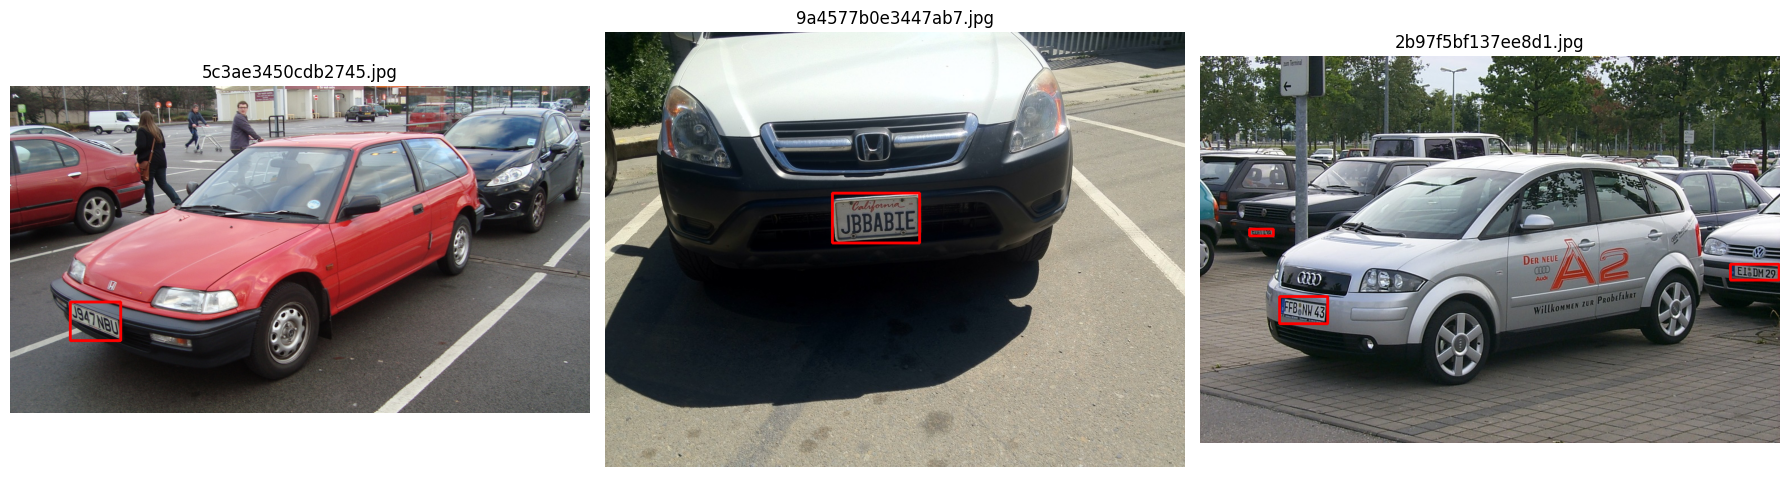

In [11]:
import random
import cv2
import matplotlib.pyplot as plt


def list_images(split: str) -> list[Path]:
    return sorted((YOLO_DATASET_DIR / "images" / split).glob("*.jpg"))


def label_path_for(img_path: Path, split: str) -> Path:
    return (YOLO_DATASET_DIR / "labels" / split / (img_path.stem + ".txt"))


for split in ["train", "val", "test"]:
    imgs = list_images(split)
    lbls = list((YOLO_DATASET_DIR / "labels" / split).glob("*.txt"))
    print(f"{split}: images={len(imgs)} labels={len(lbls)}")

# visualize a few samples
split = "val" if len(list_images("val")) else "train"
imgs = list_images(split)
if not imgs:
    raise RuntimeError("No images found in YOLO dataset. Check previous steps.")

sample_imgs = random.sample(imgs, k=min(3, len(imgs)))

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(18, 6))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    lbl_path = label_path_for(img_path, split)

    if lbl_path.exists():
        for line in lbl_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            cls, xc, yc, bw, bh = [float(x) for x in line.split()]
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10) Train YOLOv8 (export runs into `models/`)

This trains a YOLOv8 model and stores the run under `models/yolov8_custom/`.

In [12]:
# Training settings (tune as needed)
EPOCHS = 50
IMGSZ = 640
BATCH = 16  # lower if out-of-memory
WORKERS = 4
RUN_NAME = "yolov8_custom"

model = YOLO("yolov8n.pt")  # start from pretrained COCO weights

train_results = model.train(
    data=str(data_yaml_path),
    imgsz=IMGSZ,
    epochs=EPOCHS,
    batch=BATCH,
    workers=WORKERS,
    device=DEVICE,
    project=str(MODELS_DIR),
    name=RUN_NAME,
    exist_ok=True,
)

run_dir = MODELS_DIR / RUN_NAME
best_pt = run_dir / "weights" / "best.pt"
last_pt = run_dir / "weights" / "last.pt"

print("Run dir:", run_dir)
print("Best:", best_pt, best_pt.exists())
print("Last:", last_pt, last_pt.exists())

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/yolo_license_plate/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

## 11) Validate & Review Metrics

Runs validation using the best checkpoint and prints core metrics.

In [13]:
if not best_pt.exists():
    raise FileNotFoundError(best_pt)

val_model = YOLO(str(best_pt))
metrics = val_model.val(data=str(data_yaml_path), device=DEVICE)

# Ultralytics prints tables; also show the object if available
print(metrics)

# Common plots live here if generated
for plot_name in ["results.png", "confusion_matrix.png", "val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    p = run_dir / plot_name
    if p.exists():
        print("Plot:", p)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3128.1±1138.6 MB/s, size: 233.8 KB)
val: Scanning /content/data/yolo_license_plate/labels/val.cache... 724 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 724/724 216.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 4.8it/s 9.7s0.2s
                   all        724        987      0.937      0.826      0.887       0.62
Speed: 1.4ms preprocess, 4.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x787ec6ae36b0>
curves: ['Precision-Recall(B)', 'F1-Con

## 12) Run Inference on Test Images

Writes a few predictions under `models/yolov8_custom/predict/` and displays some results inline.


0: 640x640 2 license_plates, 5.1ms
1: 640x640 2 license_plates, 5.1ms
2: 640x640 1 license_plate, 5.1ms
3: 640x640 (no detections), 5.1ms
4: 640x640 (no detections), 5.1ms
5: 640x640 1 license_plate, 5.1ms
6: 640x640 2 license_plates, 5.1ms
7: 640x640 1 license_plate, 5.1ms
8: 640x640 1 license_plate, 5.1ms
9: 640x640 1 license_plate, 5.1ms
Speed: 2.5ms preprocess, 5.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/models/yolov8_custom/predict
Saved predictions: 10


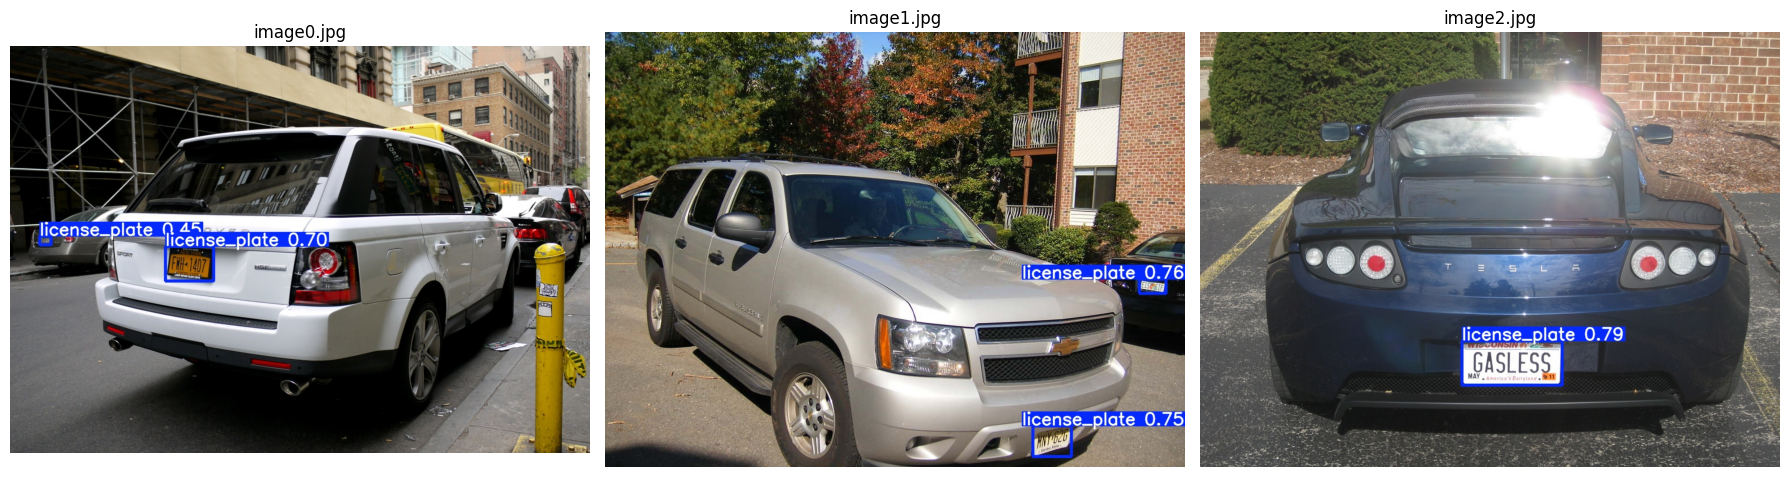

In [14]:
pred_dir = run_dir / "predict"
pred_dir.mkdir(parents=True, exist_ok=True)

test_imgs = list_images("test")
if not test_imgs:
    print("No test images found; using val split for inference")
    test_imgs = list_images("val")

sample = test_imgs[: min(10, len(test_imgs))]

pred_model = YOLO(str(best_pt))
_ = pred_model.predict(
    source=[str(p) for p in sample],
    device=DEVICE,
    conf=0.25,
    project=str(run_dir),
    name="predict",
    exist_ok=True,
    save=True,
)

# Show a couple saved predictions
saved = sorted((run_dir / "predict").glob("*.jpg"))
print("Saved predictions:", len(saved))

fig, axes = plt.subplots(1, min(3, len(saved)), figsize=(18, 6))
if len(saved) == 1:
    axes = [axes]

for ax, p in zip(axes, saved[: len(axes)]):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(p.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 13) Copy/Pin Artifacts to Stable Paths under `models/`

This creates stable filenames so downstream scripts don’t depend on run folders.

In [25]:
import os
import sys
import platform
import zipfile
import shutil

from IPython.display import FileLink, display  # type: ignore

# Stable filenames
stable_best = MODELS_DIR / "best.pt"
stable_last = MODELS_DIR / "last.pt"
stable_lp = MODELS_DIR / "license_plate_detector.pt"  # what this ANPR repo expects

if best_pt.exists():
    shutil.copy2(best_pt, stable_best)
    shutil.copy2(best_pt, stable_lp)

if last_pt.exists():
    shutil.copy2(last_pt, stable_last)

# Common results artifacts
for name in ["results.csv", "results.png"]:
    p = run_dir / name
    if p.exists():
        shutil.copy2(p, MODELS_DIR / name)

print("Environment:")
print("- sys.executable:", sys.executable)
print("- platform:", platform.platform())
print("- os.name:", os.name)
print("- CWD:", os.getcwd())
print("- ROOT:", ROOT)
print("- MODELS_DIR:", MODELS_DIR)

print("\nPinned artifacts:")
for p in [stable_lp, stable_best, stable_last, MODELS_DIR / "results.csv", MODELS_DIR / "results.png"]:
    if p.exists():
        print("-", str(p.resolve()), "bytes=", p.stat().st_size)

if not stable_lp.exists():
    raise FileNotFoundError(
        f"Expected {stable_lp} to exist. Training may not have produced best.pt yet, or ROOT/MODELS_DIR is not pointing to your workspace."
    )

# Always show a clickable link (works in many Jupyter frontends, including VS Code).
print("\nDownload link(s):")
display(FileLink(str(stable_lp)))

# Also create a zip (sometimes easier to download).
zip_path = MODELS_DIR / "license_plate_detector.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(stable_lp, arcname="license_plate_detector.pt")
print("ZIP:", str(zip_path.resolve()), "bytes=", zip_path.stat().st_size)
display(FileLink(str(zip_path)))

# If you're running in Google Colab, offer a direct browser download.
try:
    from google.colab import files  # type: ignore

    print("\nDetected Colab environment. Triggering browser download...")
    files.download(str(stable_lp))
except Exception:
    pass

print("\nNext: use the model in this repo with:")
print('  python main.py --video "./sample.mp4" --plate-model "./models/license_plate_detector.pt" --output-video out.mp4 --show --max-frames -1')

Environment:
- sys.executable: /usr/bin/python3
- platform: Linux-6.6.113+-x86_64-with-glibc2.35
- os.name: posix
- CWD: /content
- ROOT: /content
- MODELS_DIR: /content/models

Pinned artifacts:
- /content/models/license_plate_detector.pt bytes= 6236074
- /content/models/best.pt bytes= 6236074
- /content/models/last.pt bytes= 6236074
- /content/models/results.csv bytes= 6144
- /content/models/results.png bytes= 286657

Download link(s):


/content/models/license_plate_detector.pt

ZIP: /content/models/license_plate_detector.zip bytes= 5666328


/content/models/license_plate_detector.zip


Detected Colab environment. Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Next: use the model in this repo with:
  python main.py --video "./sample.mp4" --plate-model "./models/license_plate_detector.pt" --output-video out.mp4 --show --max-frames -1


## 14) Optional: Export Model (ONNX/TorchScript) into `models/exports/`

This can help if you want to run inference outside PyTorch. ONNX export requires `onnx` (and for running: `onnxruntime`).

In [22]:
exports_dir = MODELS_DIR / "exports"
exports_dir.mkdir(parents=True, exist_ok=True)

# Install optional deps if needed
%pip install -q onnx onnxruntime

if not stable_lp.exists():
    raise FileNotFoundError(stable_lp)

export_model = YOLO(str(stable_lp))

onnx_path = export_model.export(format="onnx", imgsz=IMGSZ, dynamic=False, simplify=False)
print("Exported ONNX to:", onnx_path)

# Quick load check (optional)
try:
    import onnxruntime as ort  # type: ignore

    sess = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    print("ONNXRuntime session OK. Inputs:", [i.name for i in sess.get_inputs()])
except Exception as e:
    print("ONNXRuntime not available or failed to load:", e)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/models/license_plate_detector.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: export success ✅ 0.6s, saved as '/content/models/license_plate_detector.onnx' (11.7 MB)

Export complete (0.9s)
Results saved to /content/models
Predict:         yolo predict task=detect model=/content/models/license_plate_detector.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/models/license_plate_detector.onnx imgsz=640 data=/content/data/yolo_license_plate/data.yaml  
Visualize:       https://netron.app
Exported ONNX to: /content/models/license_plate_detector.onnx
ONNXRuntime session OK. Inputs: ['images']
